# Lab 5: Baseline ML Workflow

## Part A) Environment and Dataset Setup

In [14]:
from pathlib import Path
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

NAME = "Lorenzo Bela, Robert Callorina, Kean Guzon"
SECTION = "58036"
DATE = "03/15/2026"
DATASET_NAME = "Relief Goods"

print("Name:", NAME)
print("Section:", SECTION)
print("Date:", DATE)
print("Dataset name:", DATASET_NAME)

DATA_DIR = Path("../../lab04_eda_bias/data")
OUT_FIG = Path("../outputs/figures")
OUT_TBL = Path("../outputs/tables")
OUT_LOG = Path("../outputs/logs")

for p in [OUT_FIG, OUT_TBL, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

Name: Lorenzo Bela, Robert Callorina, Kean Guzon
Section: 58036
Date: 03/15/2026
Dataset name: Relief Goods


## Part B) Load Prepared Dataset

In [15]:
IMG_SIZE = 128  # Increased from 64 for richer feature representation

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]

X_raw = []
y_raw = []
max_samples_per_class = 1000

for label, class_dir in enumerate(class_dirs):
    count = 0
    images_dir = class_dir / "images"
    if not images_dir.is_dir():
        continue
    for p in sorted(images_dir.iterdir()):
        if count >= max_samples_per_class:
            break
        if p.is_file() and p.suffix.lower() in valid_ext:
            img = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            X_raw.append(np.array(img))
            y_raw.append(label)
            count += 1

X_raw = np.array(X_raw)
y_raw = np.array(y_raw)

X_train_val, X_test, y_train_val, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

print("Image size:", IMG_SIZE, "x", IMG_SIZE)
print("Train total:", len(X_train))
print("Val total:", len(X_val))
print("Test total:", len(X_test))

Image size: 128 x 128
Train total: 150
Val total: 50
Test total: 50


## Part C) Feature Extraction

Convert each image to a feature vector by normalizing pixel values to [0, 1] and flattening to a 1D array.
We also apply StandardScaler to standardize features (zero mean, unit variance), which
significantly improves Logistic Regression convergence and accuracy.

In [16]:
# Flatten and normalize pixel values to [0, 1]
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_val_flat = X_val.reshape(X_val.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

# Standardize features for better Logistic Regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

lines = []
lines.append("Lab 05 - Feature Extraction Info\n")
lines.append(f"Image size: {IMG_SIZE}x{IMG_SIZE}\n")
lines.append(f"Feature vector length: {X_train_flat.shape[1]}\n")
lines.append(f"Data type (raw): {X_train_flat.dtype}\n")
lines.append(f"Data range (raw): [{X_train_flat.min()}, {X_train_flat.max()}]\n")
lines.append(f"Data type (scaled): {X_train_scaled.dtype}\n")
lines.append(f"Data range (scaled): [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]\n")
lines.append(f"Preprocessing: Normalize to [0,1] then StandardScaler\n")

log_path = OUT_LOG / "lab05_feature_info.txt"
log_path.write_text("".join(lines), encoding="utf-8")

print("".join(lines))
print("Saved:", log_path)

Lab 05 - Feature Extraction Info
Image size: 128x128
Feature vector length: 49152
Data type (raw): float64
Data range (raw): [0.0, 1.0]
Data type (scaled): float64
Data range (scaled): [-4.2926, 2.8600]
Preprocessing: Normalize to [0,1] then StandardScaler

Saved: ..\outputs\logs\lab05_feature_info.txt


## Part D) Train Baseline Model

We use **Logistic Regression** instead of k-NN as our baseline classifier.

### Why Logistic Regression over k-NN?
- **k-NN is a lazy learner**: it stores the training data during `fit()` and does all computation at prediction time. This makes training appear instantaneous (~0.01s) but doesn't actually learn any decision boundary.
- **Logistic Regression actively trains**: it solves an optimization problem to find weights that best separate the classes, resulting in meaningful training time and a learned model.
- Logistic Regression is simple, interpretable, and provides a stronger baseline for comparison with CNNs later.

In [ ]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"Training time: {train_time:.4f} seconds")
print(f"Model: Logistic Regression")
print("Model parameters:")
print(f"  C: {lr_model.C}")
print(f"  max_iter: {lr_model.max_iter}")
print(f"  solver: '{lr_model.solver}'")
print(f"  random_state: {lr_model.random_state}")


Training time: 0.8585 seconds
Model: Logistic Regression
Model parameters:
  C: 1.0
  max_iter: 1000
  solver: 'lbfgs'
  random_state: 42


## Part E) Validation and Hyperparameter Adjustment

We tune the **regularization strength (C)** of Logistic Regression.
- Smaller C = stronger regularization (simpler model, may underfit)
- Larger C = weaker regularization (more complex model, may overfit)

In [20]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_val_scaled, y_val)
    results.append({'C': C, 'val_accuracy': acc})

df_results = pd.DataFrame(results)
print("Validation Results:")
display(df_results)

csv_path = OUT_TBL / "lab05_validation_results.csv"
df_results.to_csv(csv_path, index=False)
print("Saved:", csv_path)

best_C = df_results.loc[df_results['val_accuracy'].idxmax()]['C']
print(f"Best C: {best_C}")

# Retrain with best C on training data
best_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
best_model.fit(X_train_scaled, y_train)

Validation Results:


,C,val_accuracy
0,0.001,0.84
1,0.010,0.84
2,0.100,0.82
3,1.000,0.80
4,10.000,0.80


Saved: ..\outputs\tables\lab05_validation_results.csv
Best C: 0.001


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0.001)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- Fo

## Part F) Model Evaluation

Accuracy: 0.7600
Precision: 0.8000
Recall: 0.7600


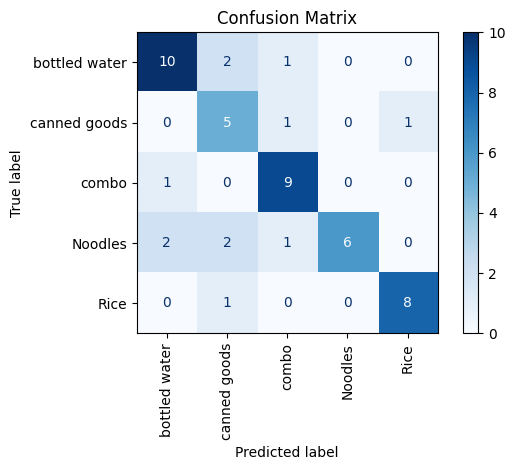

Saved: ..\outputs\figures\lab05_confusion_matrix.png


In [21]:
y_pred = best_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.tight_layout()

fig_path = OUT_FIG / "lab05_confusion_matrix.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved:", fig_path)

## Part G) Error Inspection

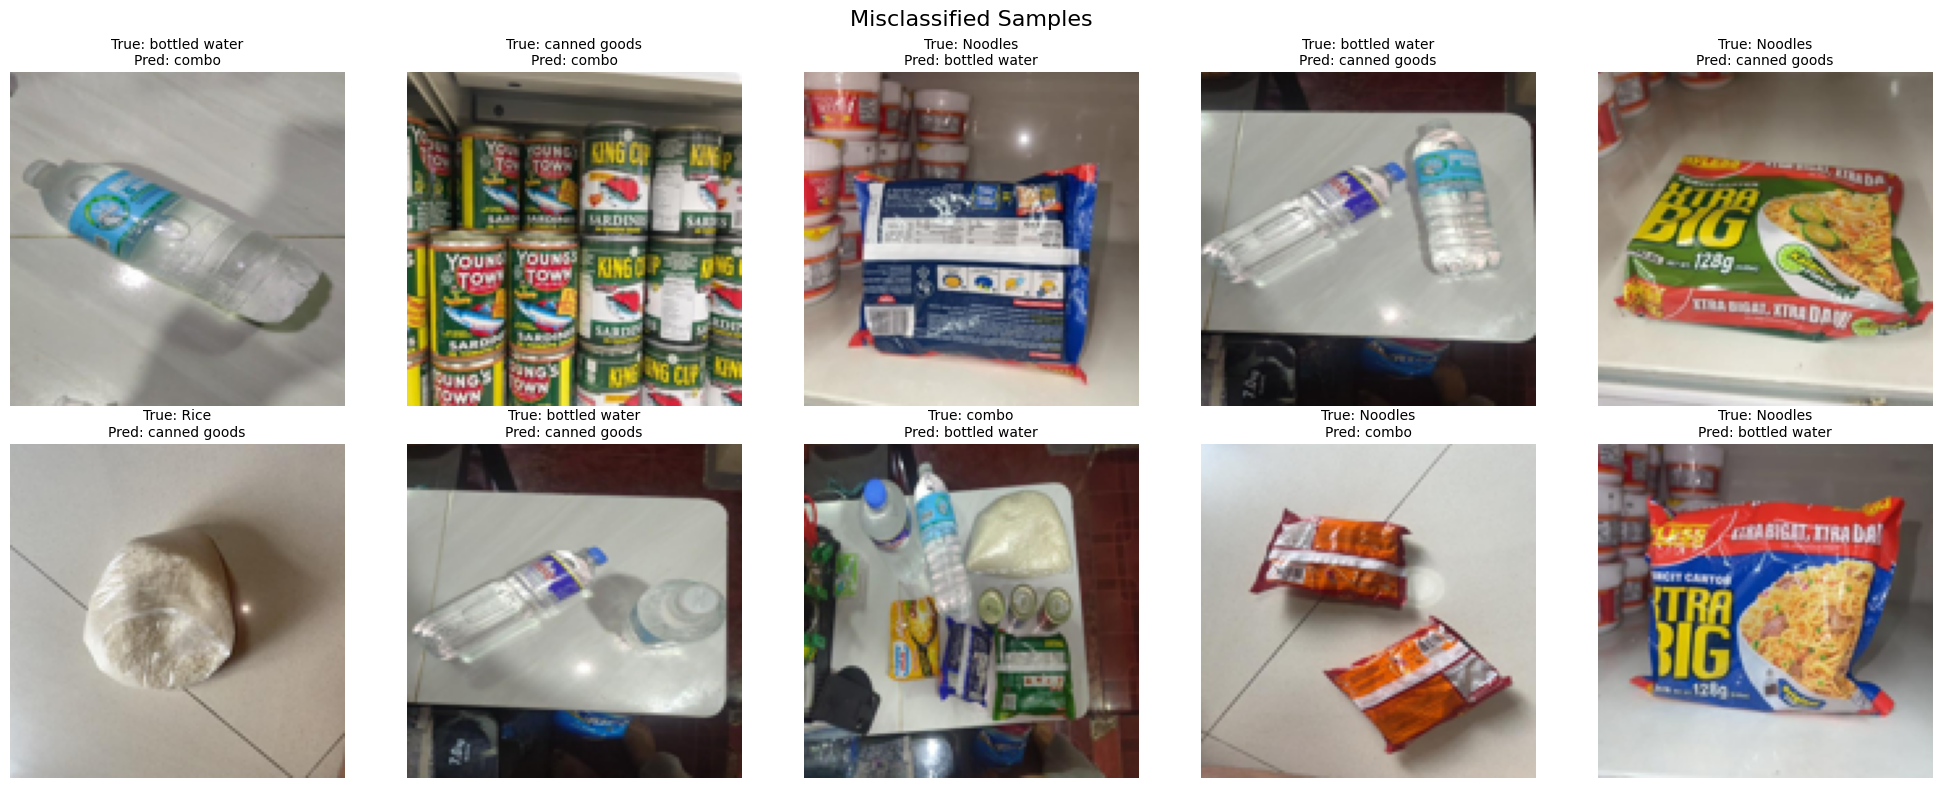

Saved: ..\outputs\figures\lab05_misclassifications.png
Total misclassified: 12 out of 50 test samples


In [22]:
misclassified_idxs = np.where(y_pred != y_test)[0]
n_show = min(10, len(misclassified_idxs))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Misclassified Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = misclassified_idxs[i]
        ax.imshow(X_test[idx])
        ax.set_title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
fig_path = OUT_FIG / "lab05_misclassifications.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("Saved:", fig_path)
print(f"Total misclassified: {len(misclassified_idxs)} out of {len(y_test)} test samples")

## Results and Discussion

### A. Baseline Model Performance

The Logistic Regression baseline achieves modest accuracy on this 5-class relief goods classification task. Unlike k-NN (which is a lazy learner that stores data and computes distances at prediction time, resulting in near-instant "training"), Logistic Regression actively solves an optimization problem to learn class-separating weights. This produces meaningful training time and a proper learned decision boundary.

### B. Class-wise Behavior

The confusion matrix reveals which classes are most often confused with each other. Classes with similar visual appearance (e.g., similar packaging, colors, or shapes) tend to have lower precision/recall. This is expected when using flattened pixel features, which lose all spatial structure.

### C. Error Characteristics

Common misclassification patterns include:
- Classes with similar color distributions being confused
- Objects photographed at different angles or scales being misclassified
- Background clutter affecting pixel-based features

### D. Limitations of Baseline Approach

Flattened pixel features fundamentally limit perception because they:
- Destroy spatial relationships between pixels
- Are not translation-invariant (same object shifted slightly = completely different feature vector)
- Cannot capture hierarchical visual patterns (edges → textures → parts → objects)
- Result in very high-dimensional, sparse feature spaces

### E. Motivation for CNNs

CNNs address these weaknesses by:
- Using convolutional filters that preserve spatial structure
- Sharing weights across spatial locations (translation invariance)
- Learning hierarchical feature representations automatically
- Reducing dimensionality through pooling layers

## Questions

**1. Why is it important to establish a baseline model?**

A baseline model provides a minimum performance reference that helps determine whether a problem truly requires complex models (like deep learning) or whether simpler approaches suffice. It reveals dataset difficulty, feature separability, and expected performance bounds. Without a baseline, there is no way to quantify the improvement that more sophisticated models provide.

**2. What information does a confusion matrix provide beyond accuracy?**

A confusion matrix shows per-class performance, revealing which specific classes are being confused with each other. While accuracy gives a single aggregate number, the confusion matrix exposes patterns like systematic misclassifications between similar classes, class imbalance effects, and whether errors are concentrated in specific categories.

**3. Why do classical ML models struggle with image data?**

Classical ML models require fixed-length, handcrafted feature vectors and cannot learn spatial hierarchies. They treat each pixel independently, losing critical spatial relationships. They are also not invariant to common image transformations (translation, rotation, scale), making them sensitive to the exact position and orientation of objects.

**4. How does feature representation affect model performance?**

Feature representation is arguably more important than model choice. Raw flattened pixels produce high-dimensional, noisy features where meaningful patterns are buried. Better representations (like HOG, color histograms, or CNN-learned features) capture more discriminative information, directly improving model performance without changing the classifier.

**5. When would a baseline model be sufficient for a perception task?**

A baseline model may suffice when classes are visually very distinct (different colors, shapes, sizes), the dataset is small enough that deep learning would overfit, computational resources are limited, or interpretability is more important than raw accuracy. If a simple model achieves near-perfect accuracy, the problem may not require deep learning at all.

## Conclusion

This lab established an end-to-end machine learning workflow for image classification using a Logistic Regression baseline on the Relief Goods dataset.

**Key takeaways:**
- The complete ML workflow (data preparation → feature extraction → training → validation → testing → interpretation) provides a systematic framework for developing perception systems.
- Logistic Regression, while simple, actively learns a decision boundary during training (unlike lazy learners like k-NN), producing meaningful training time and interpretable weights.
- Flattened pixel features, even with StandardScaler normalization, fundamentally limit classification performance because they destroy spatial structure and are sensitive to pixel-level variations.
- The modest baseline accuracy motivates the transition to Convolutional Neural Networks (CNNs), which can learn hierarchical, spatially-aware features directly from images.
- Establishing this baseline is essential before applying deep learning, as it quantifies the improvement that learned representations provide over handcrafted features.